# TTC Bus Delay EDA (2019–2024)
Exploratory data analysis of Toronto Transit Commission bus delay records across six years.

## 1. Load and Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

ModuleNotFoundError: No module named 'pandas'

In [ ]:
from pathlib import Path

# Files are expected in the same folder as this notebook.
# Change DATA_DIR if your xlsx files are elsewhere.
DATA_DIR = Path('.')

files = sorted(DATA_DIR.glob('ttc-bus-delay-data-*.xlsx'))
if not files:
    raise FileNotFoundError(
        f'No ttc-bus-delay-data-*.xlsx files found in {DATA_DIR.resolve()}\\n'
        'Place the six xlsx files in the same folder as this notebook and re-run.'
    )
print('Found files:', [f.name for f in files])

def load_and_normalise(path):
    """Load one file and rename columns to a common schema."""
    frame = pd.read_excel(path)
    frame.columns = [c.strip().lower() for c in frame.columns]
    rename_map = {
        'report date': 'date',
        'date':        'date',
        'route':       'route',
        'time':        'time',
        'day':         'day',
        'location':    'location',
        'incident':    'incident',
        'min delay':   'delay_minutes',
        'delay':       'delay_minutes',
        'min gap':     'gap_minutes',
        'gap':         'gap_minutes',
        'direction':   'direction',
        'vehicle':     'vehicle',
    }
    frame = frame.rename(columns=rename_map)
    keep = [c for c in ['date','route','time','day','location','incident',
                         'delay_minutes','gap_minutes','direction','vehicle']
            if c in frame.columns]
    return frame[keep]

frames = [load_and_normalise(f) for f in files]
df_raw = pd.concat(frames, ignore_index=True)

print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head()

Found files: ['ttc-bus-delay-data-2019.xlsx', 'ttc-bus-delay-data-2020.xlsx', 'ttc-bus-delay-data-2021.xlsx', 'ttc-bus-delay-data-2022.xlsx', 'ttc-bus-delay-data-2023.xlsx', 'ttc-bus-delay-data-2024.xlsx']
Shape: (188414, 10)
Columns: ['date', 'route', 'time', 'day', 'location', 'incident', 'delay_minutes', 'gap_minutes', 'direction', 'vehicle']


,date,route,time,day,location,incident,delay_minutes,gap_minutes,direction,vehicle
0,2019-01-01,39,00:13:00,Tuesday,NECR,Mechanical,9.0,18.0,W/B,1794.0
1,2019-01-01,111,00:15:00,Tuesday,Eglington,Mechanical,15.0,30.0,S/B,8065.0
2,2019-01-01,35,00:18:00,Tuesday,Finch,Mechanical,9.0,18.0,S/B,3275.0
3,2019-01-01,25,00:30:00,Tuesday,Don Mills Rd/Eglinton Ave E,Mechanical,9.0,18.0,N/B,8840.0
4,2019-01-01,36,00:40:00,Tuesday,Humberwood,Investigation,9.0,18.0,E/B,9119.0


In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 188414 entries, 0 to 188413
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           188414 non-null  datetime64[us]
 1   route          186838 non-null  object        
 2   time           188414 non-null  object        
 3   day            188414 non-null  str           
 4   location       188377 non-null  str           
 5   incident       188414 non-null  str           
 6   delay_minutes  188376 non-null  float64       
 7   gap_minutes    188346 non-null  float64       
 8   direction      158300 non-null  str           
 9   vehicle        186762 non-null  float64       
dtypes: datetime64[us](1), float64(3), object(2), str(4)
memory usage: 14.4+ MB


## 2. Data Cleaning and Preparation

### 2.1 Missing Values

In [ ]:
missing = df_raw.isnull().sum().rename('missing').to_frame()
missing['pct'] = (missing['missing'] / len(df_raw) * 100).round(2)
missing

,missing,pct
date,0,0.00
route,1576,0.84
time,0,0.00
day,0,0.00
location,37,0.02
incident,0,0.00
delay_minutes,38,0.02
gap_minutes,68,0.04
direction,30114,15.98
vehicle,1652,0.88


### 2.2 Fix Data Types

In [ ]:
df = df_raw.copy()

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['delay_minutes'] = pd.to_numeric(df['delay_minutes'], errors='coerce')
df['gap_minutes']   = pd.to_numeric(df['gap_minutes'],   errors='coerce')
df['route'] = df['route'].astype('category')
df['incident'] = df['incident'].fillna('Unknown').astype('category')
df['direction'] = df['direction'].fillna('Unknown').astype('category')
df['day'] = df['day'].fillna('Unknown').astype('category')

df.dtypes

date             datetime64[us]
route                  category
time                     object
day                    category
location                    str
incident               category
delay_minutes           float64
gap_minutes             float64
direction              category
vehicle                 float64
dtype: object

### 2.3 Remove Invalid Values and Duplicates

In [ ]:
before = len(df)

# Drop rows with no delay duration
df = df.dropna(subset=['delay_minutes'])

# Remove negative delays
df = df[df['delay_minutes'] >= 0]

# Remove unrealistically large delays (> 8 hours)
df = df[df['delay_minutes'] <= 480]

# Drop duplicates
df = df.drop_duplicates()

after = len(df)
print(f'Rows removed: {before - after:,}  |  Rows remaining: {after:,}')

Rows removed: 1,473  |  Rows remaining: 186,941


## 3. Create Time Variables

In [ ]:
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')
df['day_of_week'] = df['date'].dt.day_name()

# Parse hour from time column (stored as timedelta or time string)
def extract_hour(t):
    try:
        if pd.isnull(t):
            return np.nan
        if hasattr(t, 'seconds'):          # timedelta
            return t.seconds // 3600
        return int(str(t).split(':')[0])   # string
    except:
        return np.nan

df['hour'] = df['time'].apply(extract_hour)
df['rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18])

df[['date','year','month','day_of_week','hour','rush_hour','delay_minutes']].head()

,date,year,month,day_of_week,hour,rush_hour,delay_minutes
0,2019-01-01,2019,1,Tuesday,0.0,False,9.0
1,2019-01-01,2019,1,Tuesday,0.0,False,15.0
2,2019-01-01,2019,1,Tuesday,0.0,False,9.0
3,2019-01-01,2019,1,Tuesday,0.0,False,9.0
4,2019-01-01,2019,1,Tuesday,0.0,False,9.0


## 4. Basic Summary Statistics

In [ ]:
stats = df['delay_minutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
iqr = stats['75%'] - stats['25%']
print(stats)
print(f'\nIQR: {iqr:.2f} minutes')
print(f'Mean:   {stats["mean"]:.2f} min')
print(f'Median: {stats["50%"]:.2f} min')
print(f'Std:    {stats["std"]:.2f} min')

count    186941.000000
mean         18.215357
std          33.126337
min           0.000000
25%           8.000000
50%          11.000000
75%          20.000000
90%          30.000000
99%         180.000000
max         480.000000
Name: delay_minutes, dtype: float64

IQR: 12.00 minutes
Mean:   18.22 min
Median: 11.00 min
Std:    33.13 min


## 5. Distribution Analysis

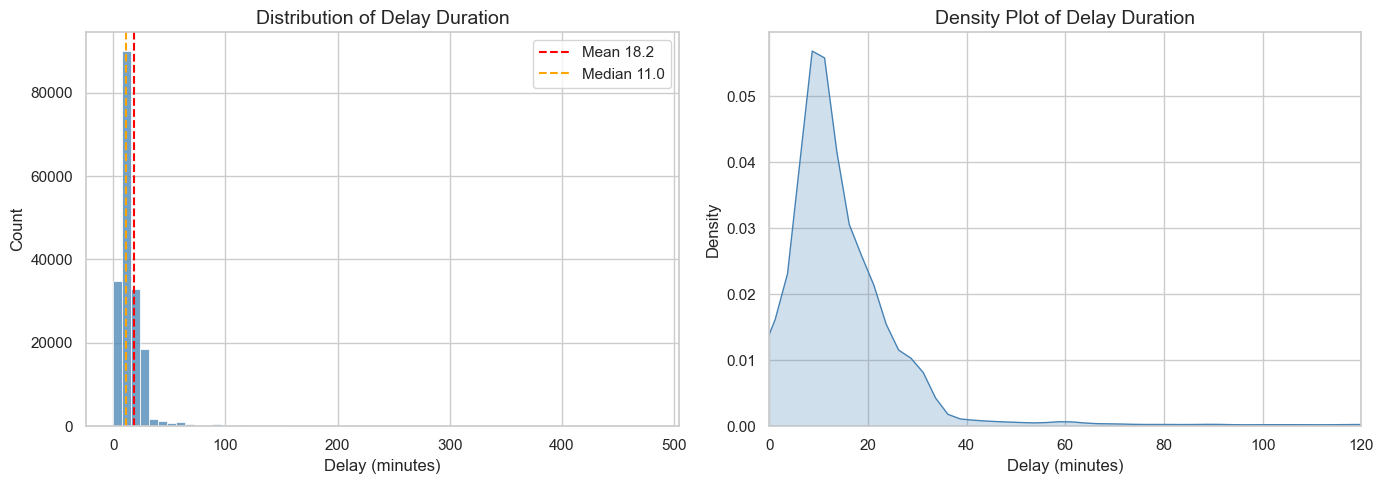

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['delay_minutes'], bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delay Duration')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['delay_minutes'].mean(),   color='red',    linestyle='--', label=f'Mean {df["delay_minutes"].mean():.1f}')
axes[0].axvline(df['delay_minutes'].median(), color='orange', linestyle='--', label=f'Median {df["delay_minutes"].median():.1f}')
axes[0].legend()

# KDE
sns.kdeplot(df['delay_minutes'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Density Plot of Delay Duration')
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_xlim(0, 120)

plt.tight_layout()
plt.show()

## 6. Time Pattern Analysis

### 6.1 Average Delay by Hour

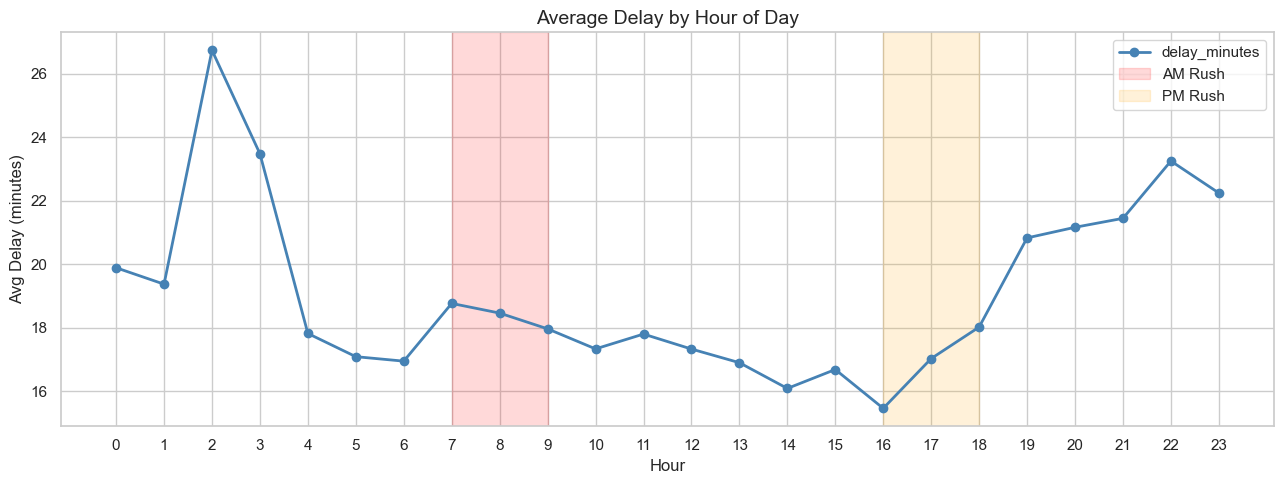

In [ ]:
hourly = df.groupby('hour')['delay_minutes'].mean().dropna()

fig, ax = plt.subplots(figsize=(13, 5))
hourly.plot(ax=ax, marker='o', color='steelblue', linewidth=2)
ax.axvspan(7, 9,   alpha=0.15, color='red',    label='AM Rush')
ax.axvspan(16, 18, alpha=0.15, color='orange',  label='PM Rush')
ax.set_title('Average Delay by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Delay (minutes)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Delay by Day of Week

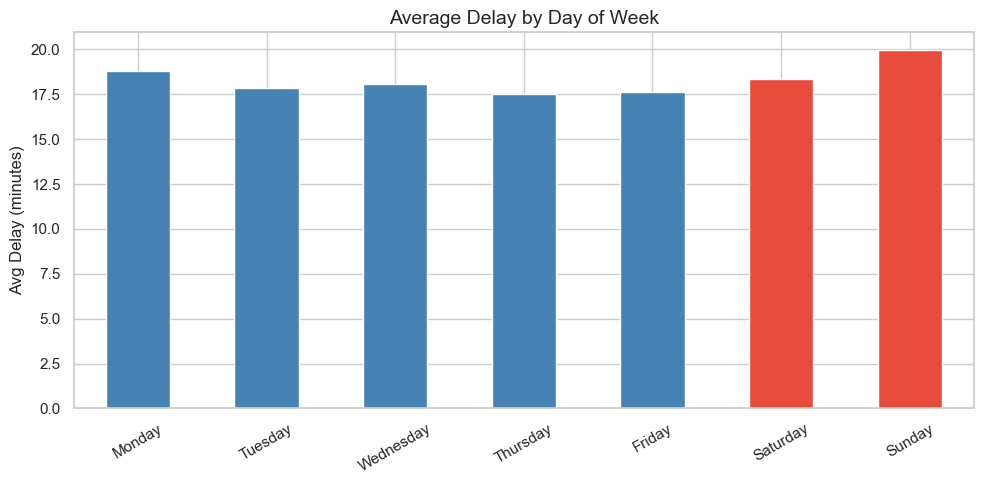

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['delay_minutes'].mean().reindex(day_order)

colors = ['#e74c3c' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]

fig, ax = plt.subplots(figsize=(10, 5))
daily.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Average Delay by Day of Week')
ax.set_xlabel('')
ax.set_ylabel('Avg Delay (minutes)')
ax.set_xticklabels(day_order, rotation=30)
plt.tight_layout()
plt.show()

### 6.3 Monthly Delay Trends

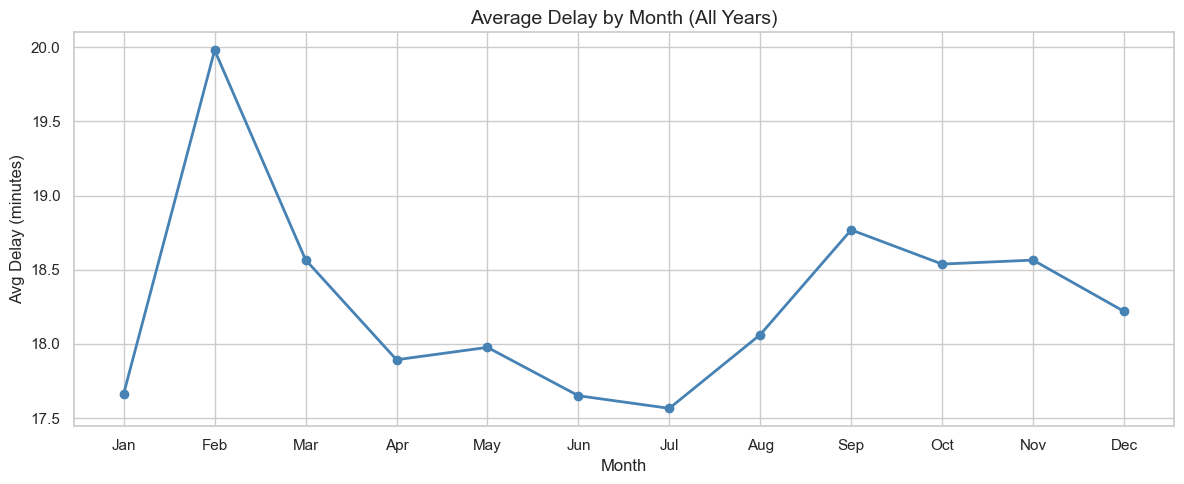

In [ ]:
monthly = df.groupby('month')['delay_minutes'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, marker='o', color='steelblue', linewidth=2)
ax.set_title('Average Delay by Month (All Years)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Delay (minutes)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
plt.tight_layout()
plt.show()

### 6.4 Annual Delay Trends (Year-over-Year)

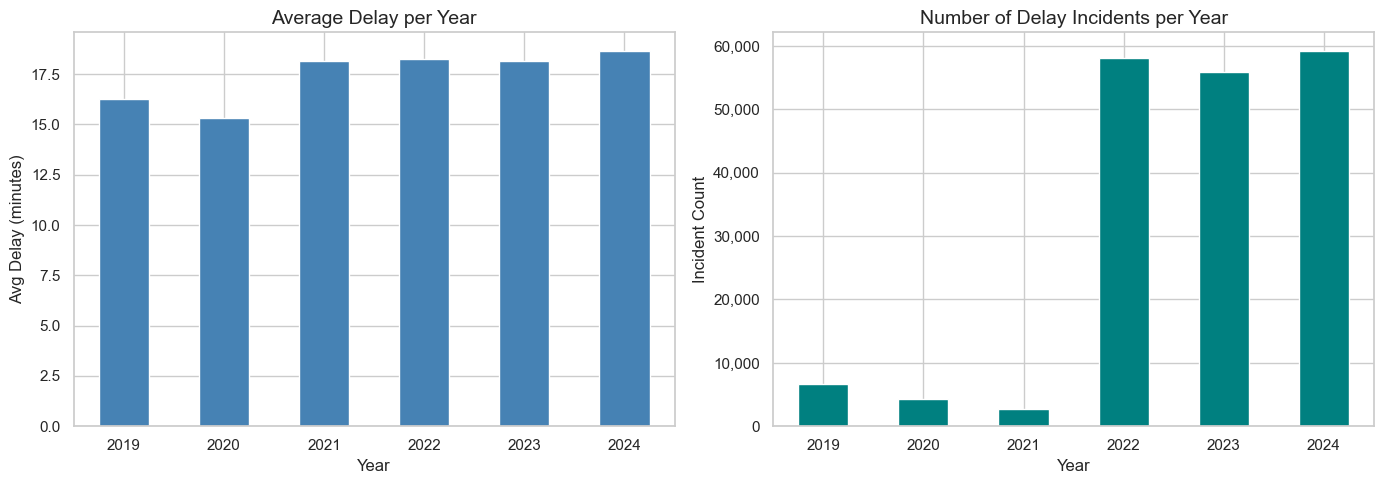

In [ ]:
yearly_avg   = df.groupby('year')['delay_minutes'].mean()
yearly_count = df.groupby('year')['delay_minutes'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_avg.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average Delay per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Delay (minutes)')
axes[0].set_xticklabels(yearly_avg.index, rotation=0)

yearly_count.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Number of Delay Incidents per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Incident Count')
axes[1].set_xticklabels(yearly_count.index, rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 7. Route Analysis

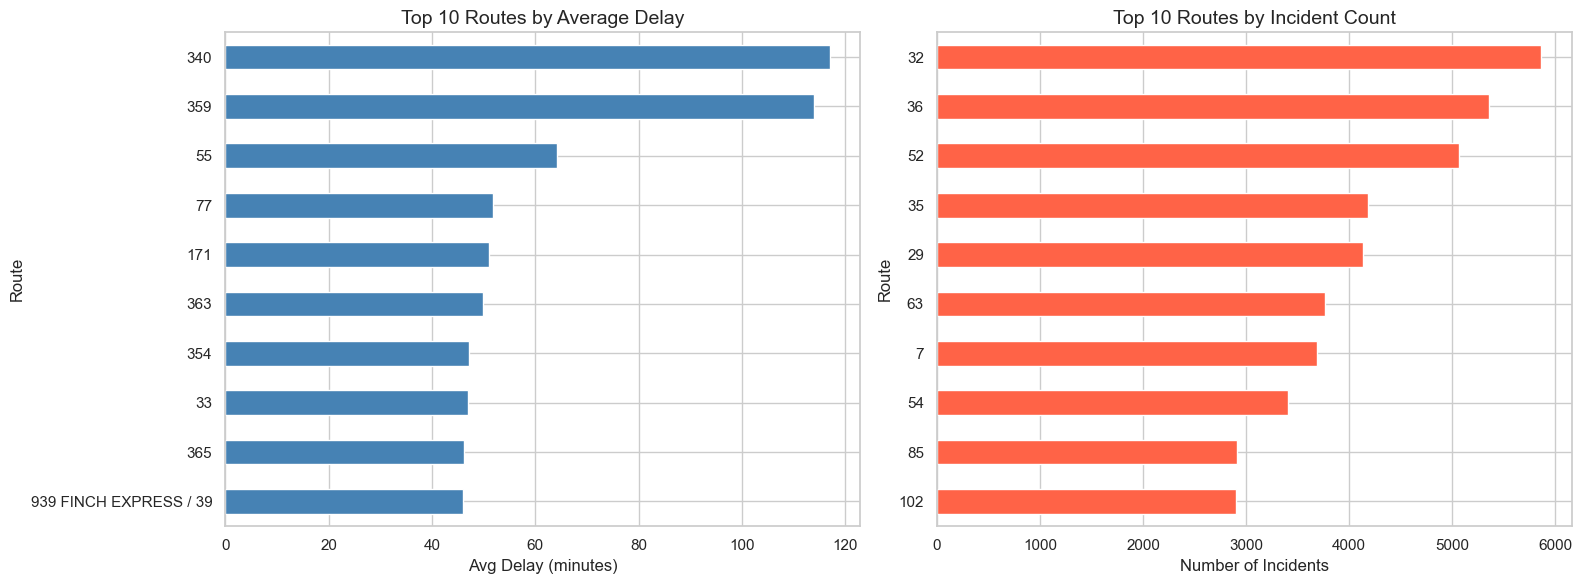

In [ ]:
route_stats = (
    df.groupby('route', observed=True)['delay_minutes']
    .agg(mean_delay='mean', incident_count='count')
    .sort_values('mean_delay', ascending=False)
)

top10_delay = route_stats.head(10)
top10_freq  = route_stats.sort_values('incident_count', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_delay['mean_delay'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Routes by Average Delay')
axes[0].set_xlabel('Avg Delay (minutes)')
axes[0].set_ylabel('Route')

top10_freq['incident_count'].plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Routes by Incident Count')
axes[1].set_xlabel('Number of Incidents')
axes[1].set_ylabel('Route')

plt.tight_layout()
plt.show()

## 8. Delay Cause Analysis

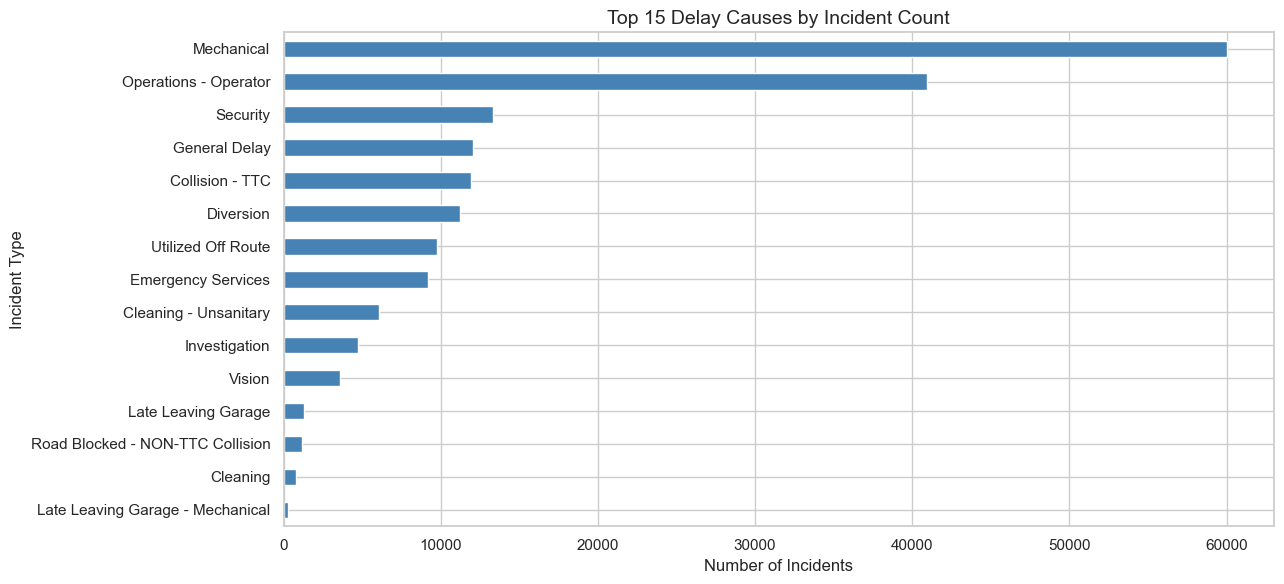

In [ ]:
cause_counts = df['incident'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
cause_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Delay Causes by Incident Count')
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('Incident Type')
plt.tight_layout()
plt.show()

## 9. Delay Duration by Cause

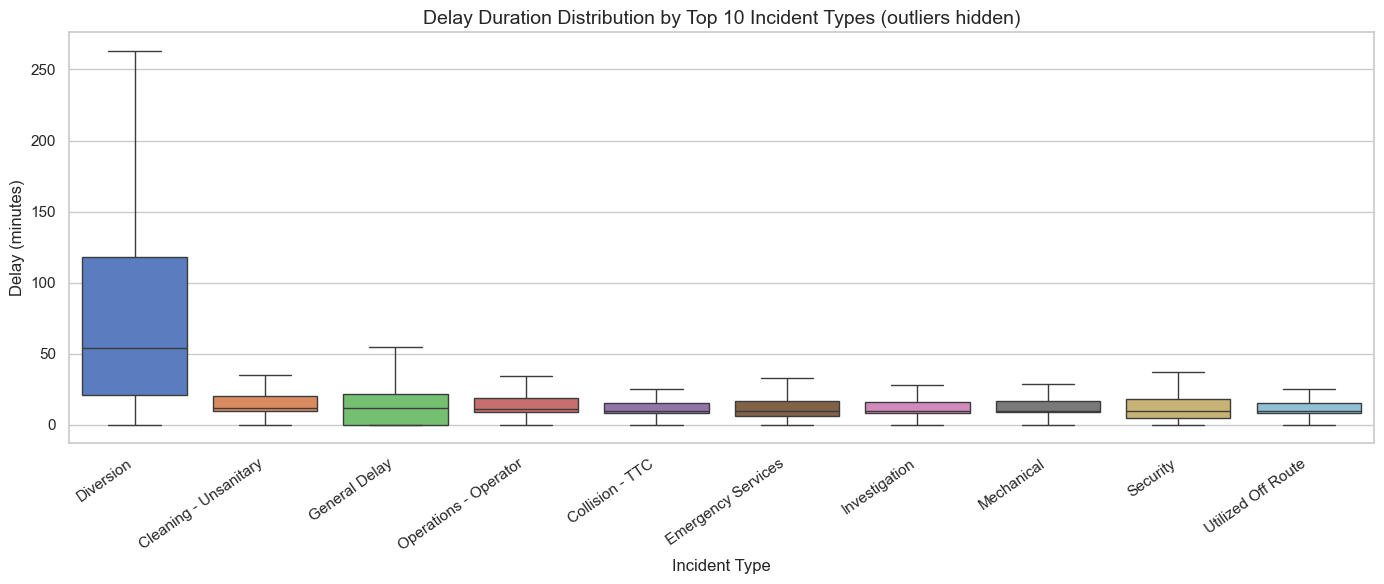

In [ ]:
top_causes = df['incident'].value_counts().head(10).index
df_top = df[df['incident'].isin(top_causes)]

fig, ax = plt.subplots(figsize=(14, 6))
order = df_top.groupby('incident', observed=True)['delay_minutes'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_top, x='incident', y='delay_minutes', order=order,
    ax=ax, palette='muted', showfliers=False
)
ax.set_title('Delay Duration Distribution by Top 10 Incident Types (outliers hidden)')
ax.set_xlabel('Incident Type')
ax.set_ylabel('Delay (minutes)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 10. Outlier Detection

Q1: 8.0 | Q3: 20.0 | IQR: 12.0
Upper fence (Q3 + 1.5×IQR): 38.0 minutes
Outlier rows: 9,036  (4.8% of data)


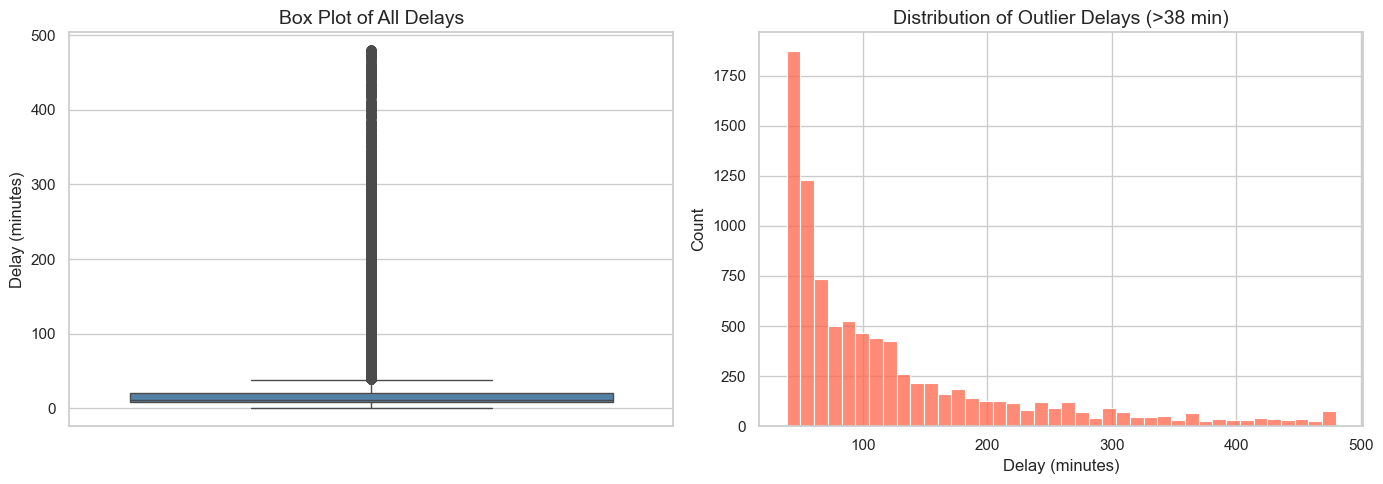

In [ ]:
Q1  = df['delay_minutes'].quantile(0.25)
Q3  = df['delay_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[df['delay_minutes'] > upper_fence]
print(f'Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}')
print(f'Upper fence (Q3 + 1.5×IQR): {upper_fence:.1f} minutes')
print(f'Outlier rows: {len(outliers):,}  ({len(outliers)/len(df)*100:.1f}% of data)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['delay_minutes'], ax=axes[0], color='steelblue')
axes[0].set_title('Box Plot of All Delays')
axes[0].set_ylabel('Delay (minutes)')

sns.histplot(outliers['delay_minutes'], bins=40, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(f'Distribution of Outlier Delays (>{upper_fence:.0f} min)')
axes[1].set_xlabel('Delay (minutes)')

plt.tight_layout()
plt.show()

In [ ]:
print('Most common causes among outlier delays:')
outliers['incident'].value_counts().head(10)

Most common causes among outlier delays:


incident
Diversion                           6723
Road Blocked - NON-TTC Collision     573
General Delay                        536
Operations - Operator                355
Mechanical                           321
Security                             111
Collision - TTC                       90
Utilized Off Route                    69
Held By                               60
Emergency Services                    57
Name: count, dtype: int64

## 11. Correlation Analysis

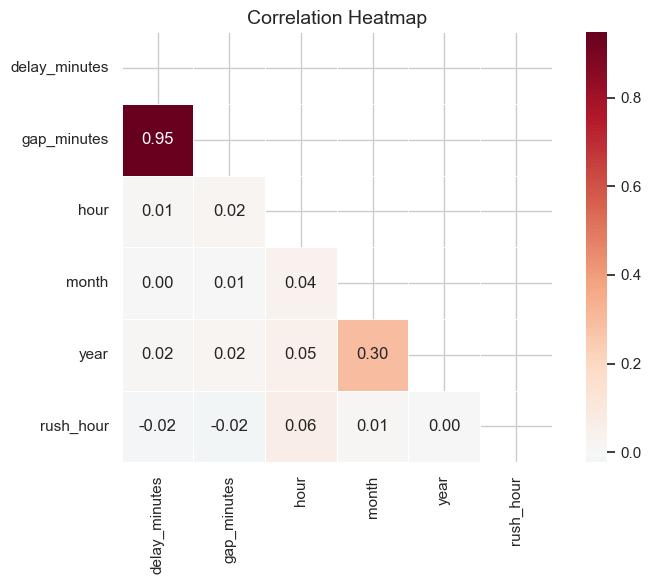

In [ ]:
corr_df = df[['delay_minutes', 'gap_minutes', 'hour', 'month', 'year']].copy()
corr_df['rush_hour'] = df['rush_hour'].astype(int)

corr = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    square=True, linewidths=0.5
)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 12. Rush Hour vs Non-Rush Hour

                mean  median   count
Non-Rush Hour  18.62    11.0  124197
Rush Hour      17.41    10.0   62744


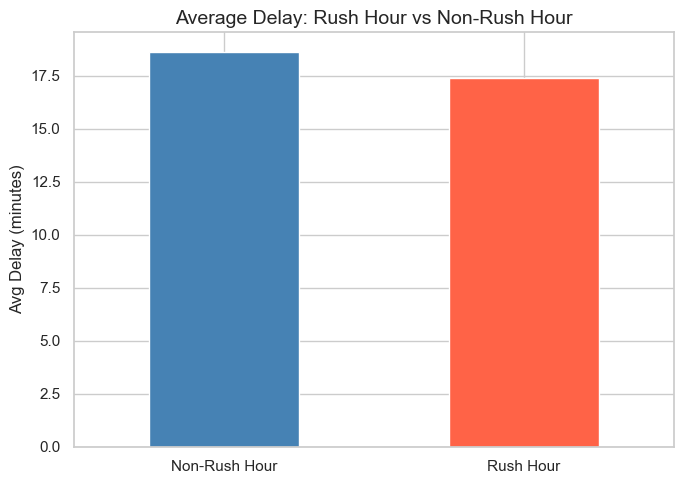

In [ ]:
rush_compare = df.groupby('rush_hour')['delay_minutes'].agg(['mean','median','count'])
rush_compare.index = ['Non-Rush Hour', 'Rush Hour']
print(rush_compare.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
rush_compare['mean'].plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
ax.set_title('Average Delay: Rush Hour vs Non-Rush Hour')
ax.set_ylabel('Avg Delay (minutes)')
ax.set_xticklabels(rush_compare.index, rotation=0)
plt.tight_layout()
plt.show()

## Key Findings Summary

In [ ]:
peak_hour   = hourly.idxmax()
peak_day    = daily.idxmax()
peak_month  = monthly.idxmax()
worst_route = route_stats['mean_delay'].idxmax()
top_cause   = df['incident'].value_counts().idxmax()
top_cause_delay = df.groupby('incident', observed=True)['delay_minutes'].mean().idxmax()

print('=' * 55)
print('TTC BUS DELAY EDA — KEY FINDINGS')
print('=' * 55)
print(f'Total clean records  : {len(df):,}')
print(f'Years covered        : {df["year"].min()} – {df["year"].max()}')
print(f'Overall mean delay   : {df["delay_minutes"].mean():.1f} min')
print(f'Overall median delay : {df["delay_minutes"].median():.1f} min')
print()
print(f'Peak hour            : {peak_hour}:00 ({hourly[peak_hour]:.1f} min avg)')
print(f'Worst day of week    : {peak_day}')
print(f'Worst month          : {month_labels[peak_month-1]}')
print(f'Worst route (avg)    : Route {worst_route} ({route_stats.loc[worst_route,"mean_delay"]:.1f} min avg)')
print(f'Most frequent cause  : {top_cause}')
print(f'Cause w/ longest avg : {top_cause_delay}')
print(f'Outlier incidents    : {len(outliers):,} (>{upper_fence:.0f} min)')
print('=' * 55)

TTC BUS DELAY EDA — KEY FINDINGS
Total clean records  : 186,941
Years covered        : 2019 – 2024
Overall mean delay   : 18.2 min
Overall median delay : 11.0 min

Peak hour            : 2.0:00 (26.7 min avg)
Worst day of week    : Sunday
Worst month          : Feb
Worst route (avg)    : Route 340 (117.0 min avg)
Most frequent cause  : Mechanical
Cause w/ longest avg : Cleaning - Disinfection
Outlier incidents    : 9,036 (>38 min)


# Methods

Patterns in EDA to look into:
- Delay duration is right-skewed
- Most delays are short, with a small number of extreme values
- Rush hour has minimal impact on delay duration
- Longest delays occur at hours 2, 3, and 22
- Monday and Sunday have the longest delays (differences are small)
- February has the highest delays (by a large margin) - Followed by: March, September, October
- Delay incidents have increased significantly since 2021
- Average delay per year is consistent, except 2020 (COVID) and 2024 (slightly highest average)
- Routes with most significant delays: 340, 359, 56, 77, 171, 363
- Route 340 has the highest average delay
- Diversion has the longest delays - Followed by: General delay, Emergency services, Security
- Mechanical, Operations, Security, General delay happen most frequently
- Strong correlation between Delay minutes & gap minutes








# Relationship Between Delay and Gap

Correlation Coefficient between incident delay and resulting service gaps represents a very strong positive correlation, suggesting that approximately 90% of the variance in service gaps can be explained by the duration of the initial delay. This finding highlights that once a delay occurs, it almost inevitably results in an equivalent loss of service frequency for the passenger.

# Log Transforation

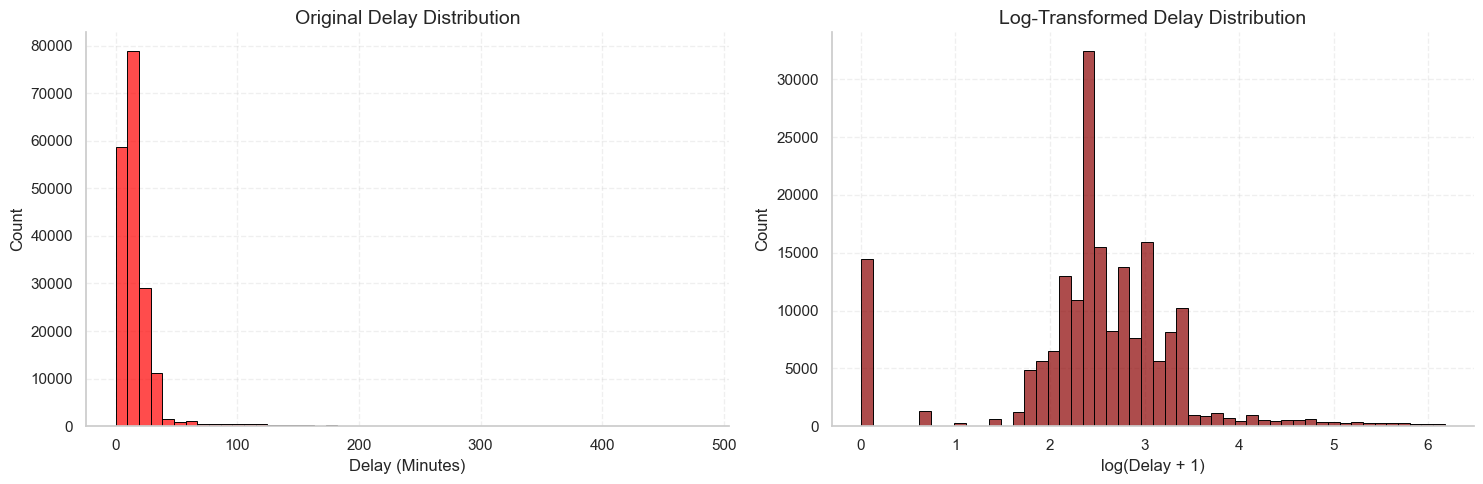

In [ ]:
df['log_delay'] = np.log1p(df['delay_minutes'])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['delay_minutes'], bins=50, ax=ax[0],
             color='red', edgecolor='black', alpha=0.7)
ax[0].set_title("Original Delay Distribution")
ax[0].set_xlabel("Delay (Minutes)")
ax[0].set_ylabel("Count")

sns.histplot(df['log_delay'], bins=50, ax=ax[1],
             color='darkred', edgecolor='black', alpha=0.7)
ax[1].set_title("Log-Transformed Delay Distribution")
ax[1].set_xlabel("log(Delay + 1)")
ax[1].set_ylabel("Count")

for a in ax:
    a.grid(True, linestyle='--', alpha=0.3)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Due to the strong right-skewed distribution of delay duration observed during EDA, a logarithmic transformation was applied. This transformation reduced the influence of extreme delays and produced a more stable distribution suitable for modeling. Splitting the data into separate delay groups was considered but not implemented, as the log transformation sufficiently addressed the skewness.

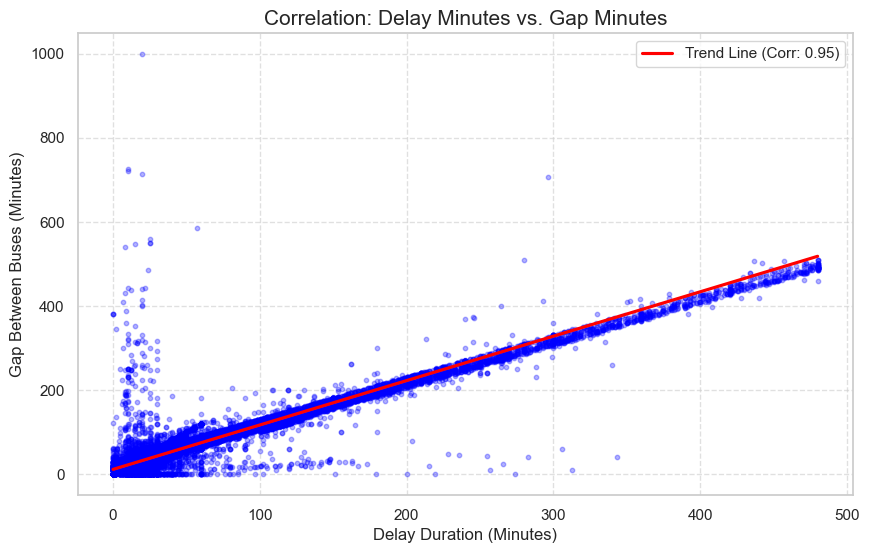

Correlation Coefficient: 0.9471


In [ ]:
correlation = df[['delay_minutes', 'gap_minutes']].corr().iloc[0, 1]

plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='delay_minutes', y='gap_minutes', 
            scatter_kws={'alpha':0.3, 's':10, 'color':'blue'}, 
            line_kws={'color':'red', 'label': f'Trend Line (Corr: {correlation:.2f})'})

plt.title('Correlation: Delay Minutes vs. Gap Minutes', fontsize=15)
plt.xlabel('Delay Duration (Minutes)', fontsize=12)
plt.ylabel('Gap Between Buses (Minutes)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Correlation Coefficient: {correlation:.4f}")

# Routes

Compare mean and variability:

Top 10 Routes by Average Delay:


,mean,std,count
route,,,
55,64.238994,97.301857,159
77,51.776744,95.672418,215
363,49.875000,59.400351,104
33,46.986239,73.371379,218
162,44.208531,63.105310,211
14,42.450382,67.270372,655
167,42.446602,54.539085,206
93,42.168067,77.055045,119
28,41.327103,56.465848,107


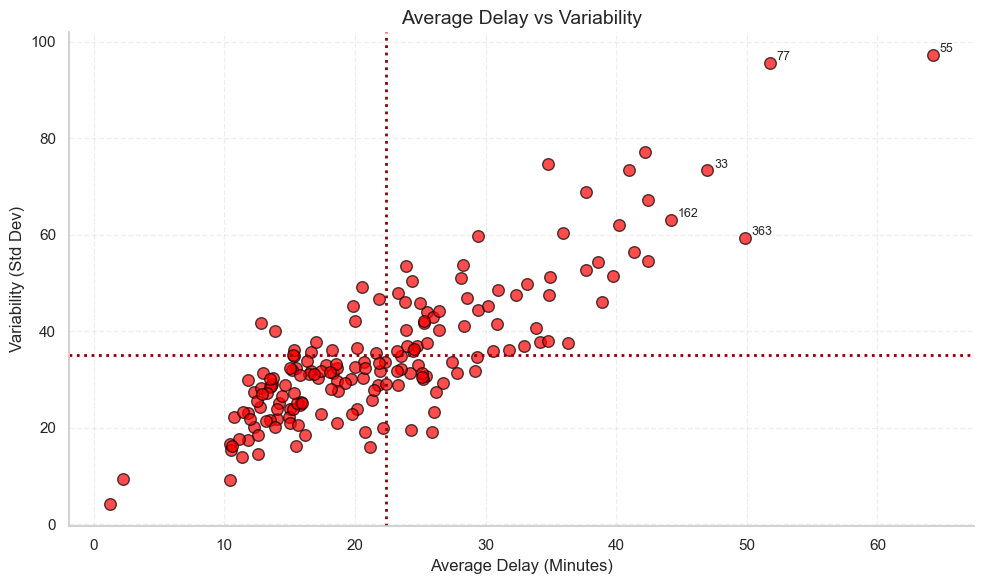

In [ ]:
route_stats = df.groupby("route")["delay_minutes"].agg(["mean", "std", "count"])
route_stats_filtered = route_stats[route_stats["count"] > 100]

print("Top 10 Routes by Average Delay:")
display(route_stats_filtered.sort_values("mean", ascending=False).head(10))

plt.figure(figsize=(10, 6))

x = route_stats_filtered["mean"]
y = route_stats_filtered["std"]

plt.scatter(x, y, color='red', alpha=0.7, s=70, edgecolor='black')

plt.axvline(x=x.mean(), color='darkred', linestyle=':', linewidth=2)
plt.axhline(y=y.mean(), color='darkred', linestyle=':', linewidth=2)

top_routes = route_stats_filtered.sort_values("mean", ascending=False).head(5)

for route in top_routes.index:
    plt.text(route_stats_filtered.loc[route, "mean"] + 0.5,
             route_stats_filtered.loc[route, "std"] + 0.5,
             str(route),
             fontsize=9)

plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Variability (Std Dev)")
plt.title("Average Delay vs Variability")

plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- High mean and high std: consistently bad and unreliable (worst case)
- High mean and low std: bad but predictable
- Low mean and high std: inconsistent system

Route-Cause interaction:

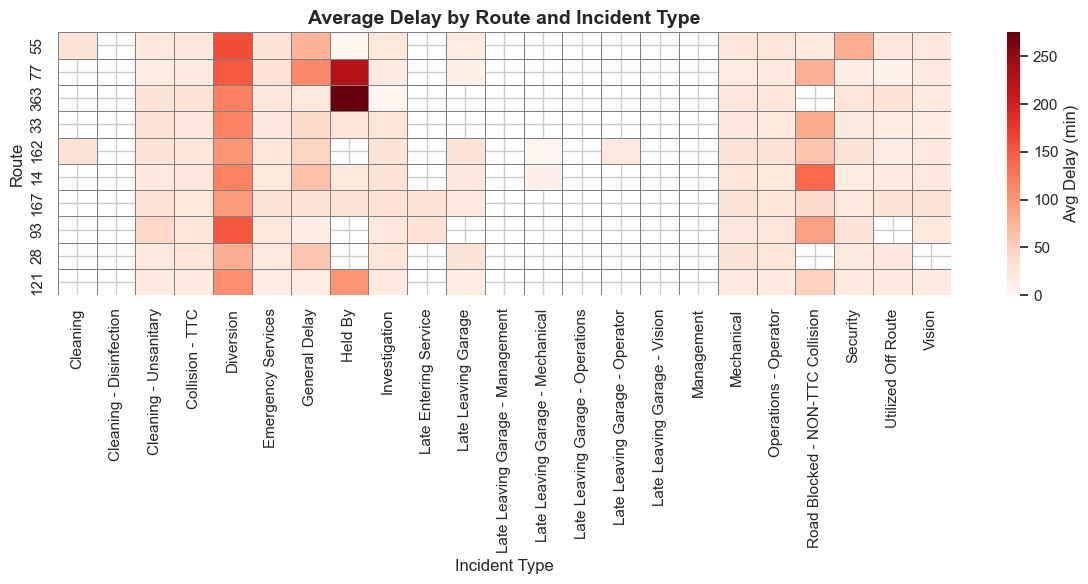

In [ ]:
top_routes = route_stats_filtered.sort_values("mean", ascending=False).head(10).index

route_incident = pd.crosstab(
    df["route"], df["incident"],
    values=df["delay_minutes"], aggfunc="mean"
)

route_incident = route_incident.loc[top_routes]

plt.figure(figsize=(12, 6))

sns.heatmap(
    route_incident,
    cmap="Reds",                              
    linewidths=0.5,           
    linecolor='gray',
    cbar_kws={'label': 'Avg Delay (min)'}
)

plt.title("Average Delay by Route and Incident Type", fontsize=14, fontweight='bold')
plt.xlabel("Incident Type")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

# Route 77 and 55

In [ ]:
route_77 = df[df["route"] == 77]
route_55 = df[df["route"] == 55]
print("Route 77 stats:")
print(route_77["delay_minutes"].describe())

print("\nRoute 55 stats:")
print(route_55["delay_minutes"].describe())

Route 77 stats:
count    215.000000
mean      51.776744
std       95.672418
min        0.000000
25%       10.000000
50%       15.000000
75%       30.000000
max      480.000000
Name: delay_minutes, dtype: float64

Route 55 stats:
count    159.000000
mean      64.238994
std       97.301857
min        0.000000
25%       20.000000
50%       30.000000
75%       35.500000
max      457.000000
Name: delay_minutes, dtype: float64


In [ ]:
r77_causes = route_77.groupby("incident")["delay_minutes"].mean().sort_values(ascending=False)
r55_causes = route_55.groupby("incident")["delay_minutes"].mean().sort_values(ascending=False)

display(r77_causes)
display(r55_causes)

incident
Held By                             226.000000
Diversion                           150.075000
General Delay                       109.789474
Road Blocked - NON-TTC Collision     78.000000
Emergency Services                   31.333333
Vision                               20.000000
Operations - Operator                17.972222
Collision - TTC                      17.785714
Investigation                        17.500000
Mechanical                           17.123077
Cleaning - Unsanitary                15.200000
Security                             13.111111
Late Leaving Garage                   9.000000
Utilized Off Route                    5.000000
Name: delay_minutes, dtype: float64

incident
Diversion                           159.500000
Security                             79.833333
General Delay                        76.000000
Cleaning                             30.000000
Emergency Services                   29.272727
Operations - Operator                25.950000
Mechanical                           25.516129
Investigation                        24.400000
Vision                               22.000000
Utilized Off Route                   22.000000
Collision - TTC                      21.875000
Cleaning - Unsanitary                21.250000
Road Blocked - NON-TTC Collision     20.000000
Late Leaving Garage                  16.800000
Held By                               0.000000
Name: delay_minutes, dtype: float64

# Years

In [ ]:
avg_delay = df.groupby("year")["delay_minutes"].mean()
print("Average delay per year:")
print(avg_delay)


Average delay per year:
year
2019    16.256686
2020    15.307348
2021    18.139385
2022    18.270115
2023    18.163914
2024    18.643730
Name: delay_minutes, dtype: float64


In [ ]:
drop_2020 = ((avg_delay[2020] - avg_delay[2019]) / avg_delay[2019]) * 100
print(f"Percent change from 2019 to 2020: {drop_2020:.2f}%")

Percent change from 2019 to 2020: -5.84%


In [ ]:
change_2024 = ((avg_delay[2024] - avg_delay[2019]) / avg_delay[2019]) * 100
print(f"Percent change from 2019 to 2024: {change_2024:.2f}%")

Percent change from 2019 to 2024: 14.68%


# Months

,mean,std,median,count
month,,,,
2,19.978553,39.472260,11.0,12263
9,18.768286,34.273090,11.0,15066
3,18.566968,37.388514,11.0,12939
11,18.564839,34.353493,11.0,14374
10,18.538065,32.670478,11.0,14922
12,18.219594,32.078270,11.0,14882
8,18.062694,31.182743,11.0,16429
5,17.977030,32.466813,10.0,13931
4,17.893612,31.622105,11.0,12868


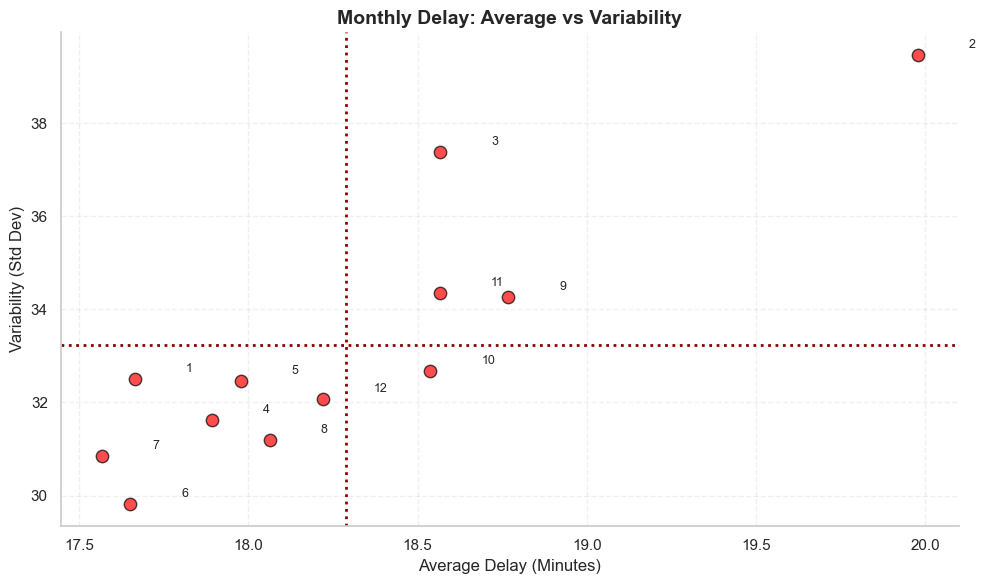

In [ ]:
month_stats = df.groupby("month")["delay_minutes"].agg(["mean", "std", "median", "count"])
month_stats = month_stats.sort_values("mean", ascending=False)

display(month_stats)

plt.figure(figsize=(10, 6))

x = month_stats["mean"]
y = month_stats["std"]

plt.scatter(x, y, color='red', alpha=0.7, s=80, edgecolor='black')

x_mean = x.mean()
y_mean = y.mean()
plt.axvline(x=x_mean, color='darkred', linestyle=':', linewidth=2)
plt.axhline(y=y_mean, color='darkred', linestyle=':', linewidth=2)

for i, month in enumerate(month_stats.index):
    plt.text(x.iloc[i] + 0.15,
             y.iloc[i] + 0.15,
             str(month),
             fontsize=9)

plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Variability (Std Dev)")
plt.title("Monthly Delay: Average vs Variability", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- High mean and high std: consistently bad and unreliable (worst case)
- High mean and low std: bad but predictable
- Low mean and high std: inconsistent system

Incident Type vs Month:

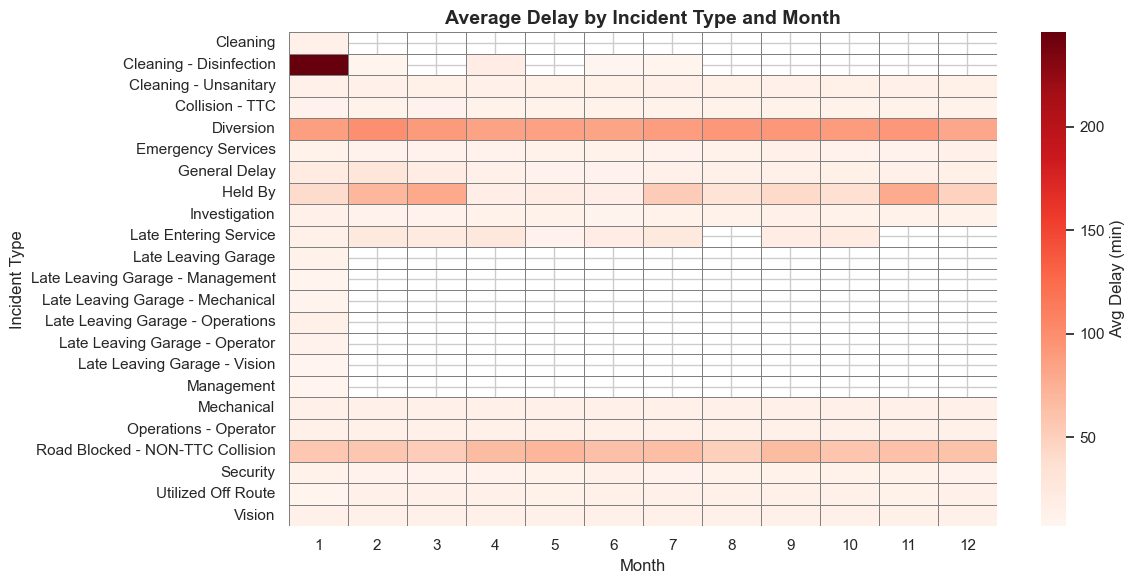

In [ ]:
cause_month = df.groupby(["incident", "month"])["delay_minutes"].mean().unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(
    cause_month,
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Avg Delay (min)'}
)

plt.title("Average Delay by Incident Type and Month", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Incident Type")

plt.tight_layout()
plt.show()

Consistantly bad vs occasionally bad Months:

In [ ]:
extreme = df[df["delay_minutes"] > 60]
extreme.groupby("month")["delay_minutes"].count().sort_index()

month
1     807
2     487
3     413
4     397
5     449
6     480
7     465
8     515
9     537
10    501
11    478
12    473
Name: delay_minutes, dtype: int64

# February

In [ ]:
feb = df[df["month"] == 2]
feb["delay_minutes"].describe()

count    12263.000000
mean        19.978553
std         39.472260
min          0.000000
25%          8.000000
50%         11.000000
75%         20.000000
max        480.000000
Name: delay_minutes, dtype: float64

In [ ]:
feb_incidents = feb.groupby("incident")["delay_minutes"].agg(["mean", "count"]).sort_values("mean", ascending=False)
display(feb_incidents)

,mean,count
incident,,
Diversion,98.965995,794
Held By,69.823529,34
Road Blocked - NON-TTC Collision,57.876712,73
General Delay,28.719424,695
Late Entering Service,24.000000,1
Operations - Operator,14.386858,2435
Vision,13.922727,220
Cleaning - Unsanitary,13.902597,308
Mechanical,13.320801,4442


February and Route:

In [ ]:
feb.groupby("route")["delay_minutes"].mean().sort_values(ascending=False).head(10)

route
YU     225.000000
55     119.733333
14      95.696970
77      88.470588
115     85.166667
363     78.800000
82      76.700000
33      73.115385
336     70.250000
352     67.636364
Name: delay_minutes, dtype: float64

# Hour

Rush hour vs non-rush hour (confirming little significance):

In [ ]:
rush = df[df["rush_hour"] == 1]["delay_minutes"]
non_rush = df[df["rush_hour"] == 0]["delay_minutes"]
mean_diff = rush.mean() - non_rush.mean()
print(f"Mean difference: {mean_diff:.2f}")

Mean difference: -1.21


,mean,std,median,count
hour,,,,
2.0,26.747083,45.359242,17.0,2657
3.0,23.484352,34.432655,17.0,2013
22.0,23.255639,37.618433,14.0,5320
23.0,22.247384,31.788794,14.0,4491
21.0,21.448824,39.708721,12.0,6673
20.0,21.166782,40.718917,12.0,7243
19.0,20.831979,43.953009,11.0,8124
0.0,19.891771,24.984448,14.0,3585
1.0,19.373957,34.692446,12.0,2757


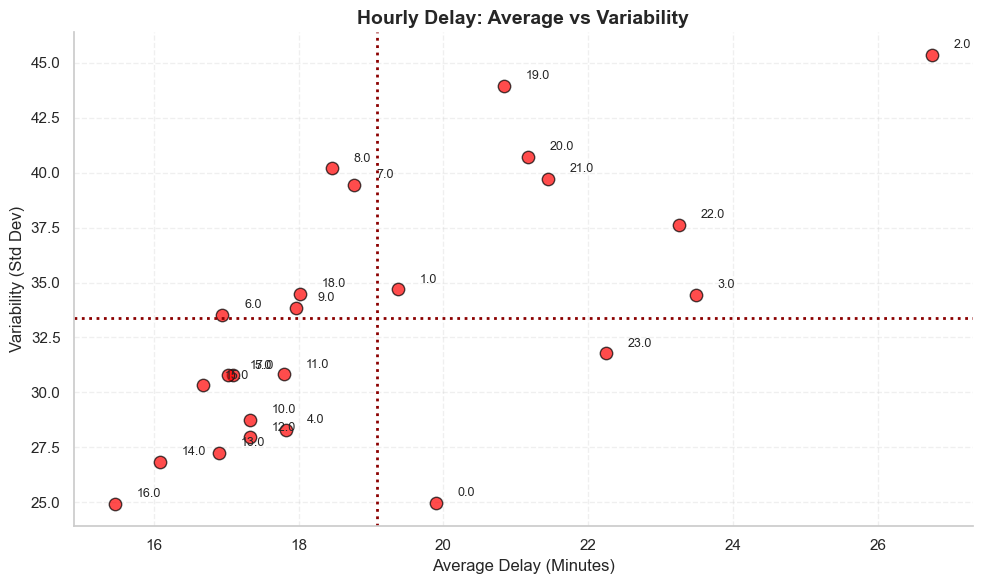

In [ ]:
hour_stats = df.groupby("hour")["delay_minutes"].agg(["mean", "std", "median", "count"])
hour_stats = hour_stats.sort_values("mean", ascending=False)

display(hour_stats)

plt.figure(figsize=(10, 6))

x = hour_stats["mean"]
y = hour_stats["std"]

plt.scatter(x, y, color='red', alpha=0.7, s=80, edgecolor='black')

x_mean = x.mean()
y_mean = y.mean()
plt.axvline(x=x_mean, color='darkred', linestyle=':', linewidth=2)
plt.axhline(y=y_mean, color='darkred', linestyle=':', linewidth=2)

for i, hour in enumerate(hour_stats.index):
    plt.text(x.iloc[i] + 0.3,
             y.iloc[i] + 0.3,
             str(hour),
             fontsize=9)

plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Variability (Std Dev)")
plt.title("Hourly Delay: Average vs Variability", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

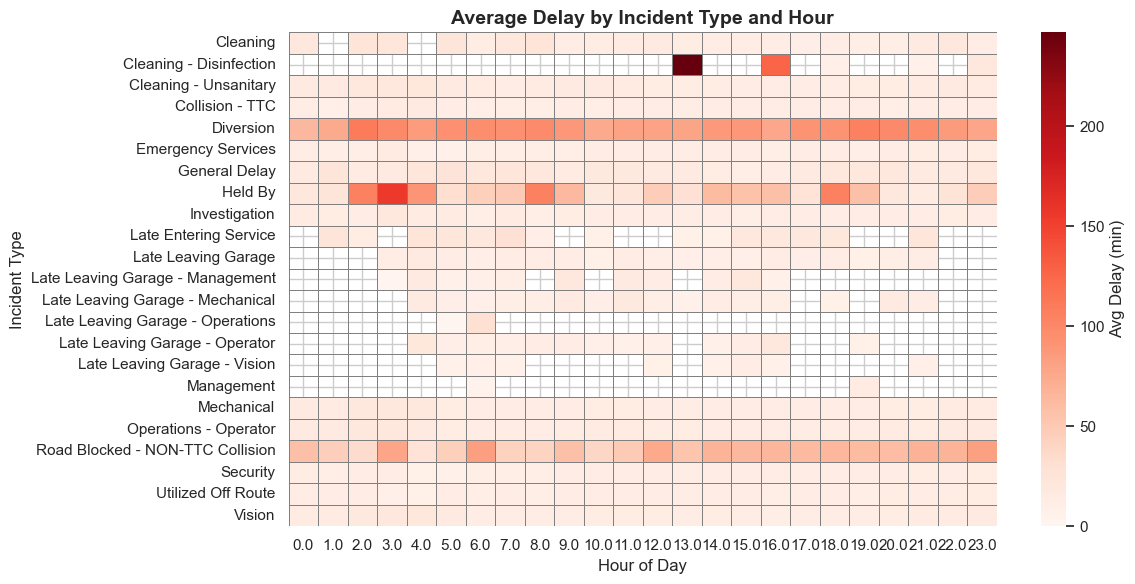

In [ ]:
cause_hour = df.groupby(["incident", "hour"])["delay_minutes"].mean().unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(
    cause_hour,
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Avg Delay (min)'}
)

plt.title("Average Delay by Incident Type and Hour", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Incident Type")

plt.tight_layout()
plt.show()

# Hour 2

In [ ]:
hour2 = df[df["hour"] == 2]
hour2["delay_minutes"].describe()

count    2657.000000
mean       26.747083
std        45.359242
min         0.000000
25%         3.000000
50%        17.000000
75%        30.000000
max       425.000000
Name: delay_minutes, dtype: float64

In [ ]:
hour2_incidents = hour2.groupby("incident")["delay_minutes"].agg(["mean", "count"]).sort_values("mean", ascending=False)
display(hour2_incidents)

,mean,count
incident,,
Diversion,110.037152,323
Held By,105.666667,3
Road Blocked - NON-TTC Collision,34.142857,14
Cleaning,25.000000,2
Cleaning - Unsanitary,19.729323,133
Operations - Operator,19.333333,450
Mechanical,18.601881,319
Vision,17.582090,67
General Delay,15.381356,118


In [ ]:
hour2.groupby("route")["delay_minutes"].mean().sort_values(ascending=False).head(10)

route
952    294.000000
340    117.000000
122     97.333333
91      81.000000
111     81.000000
336     73.580000
315     71.333333
337     70.380952
332     70.078947
302     69.333333
Name: delay_minutes, dtype: float64

# Diversion

In [ ]:
diversion = df[df["incident"] == "Diversion"]
diversion["delay_minutes"].describe()

count    11238.000000
mean        88.812066
std         98.884602
min          0.000000
25%         21.000000
50%         54.000000
75%        118.000000
max        480.000000
Name: delay_minutes, dtype: float64

In [ ]:
print("Diversion mean:", diversion["delay_minutes"].mean())
print("Overall mean:", df["delay_minutes"].mean())

Diversion mean: 88.81206620395088
Overall mean: 18.215356716825095


In [ ]:
print("Diversion count:", len(diversion))
print("Total count:", len(df))

Diversion count: 11238
Total count: 186941


High delay and high frequency = major system issue

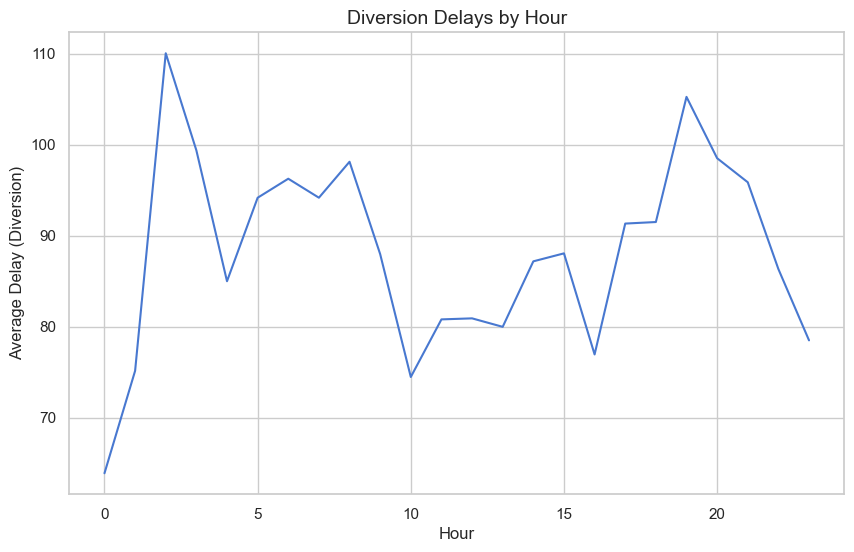

In [ ]:
div_hour = diversion.groupby("hour")["delay_minutes"].mean()
div_hour = div_hour.sort_index()

plt.figure(figsize=(10,6))
plt.plot(div_hour.index, div_hour.values)
plt.xlabel("Hour")
plt.ylabel("Average Delay (Diversion)")
plt.title("Diversion Delays by Hour")
plt.grid(True)
plt.show()

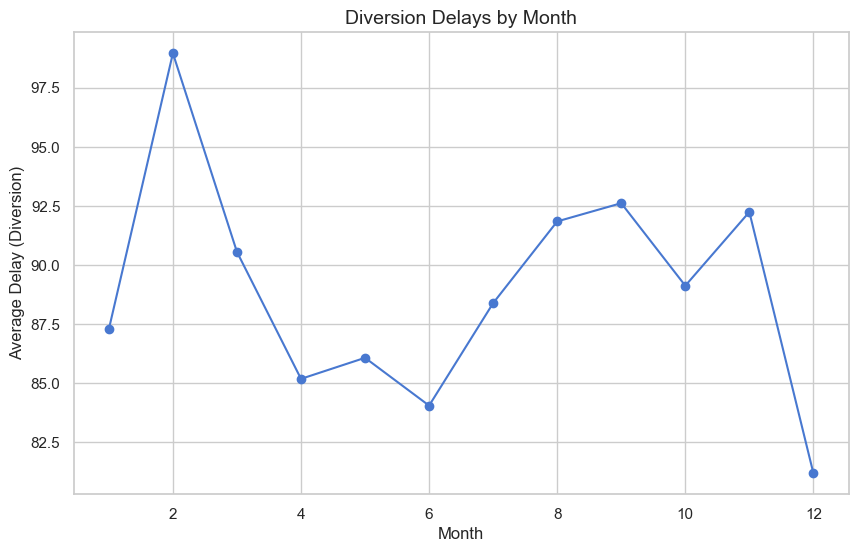

In [ ]:
div_month = diversion.groupby("month")["delay_minutes"].mean()
div_month = div_month.sort_index()

plt.figure(figsize=(10,6))
plt.plot(div_month.index, div_month.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Average Delay (Diversion)")
plt.title("Diversion Delays by Month")
plt.grid(True)
plt.show()

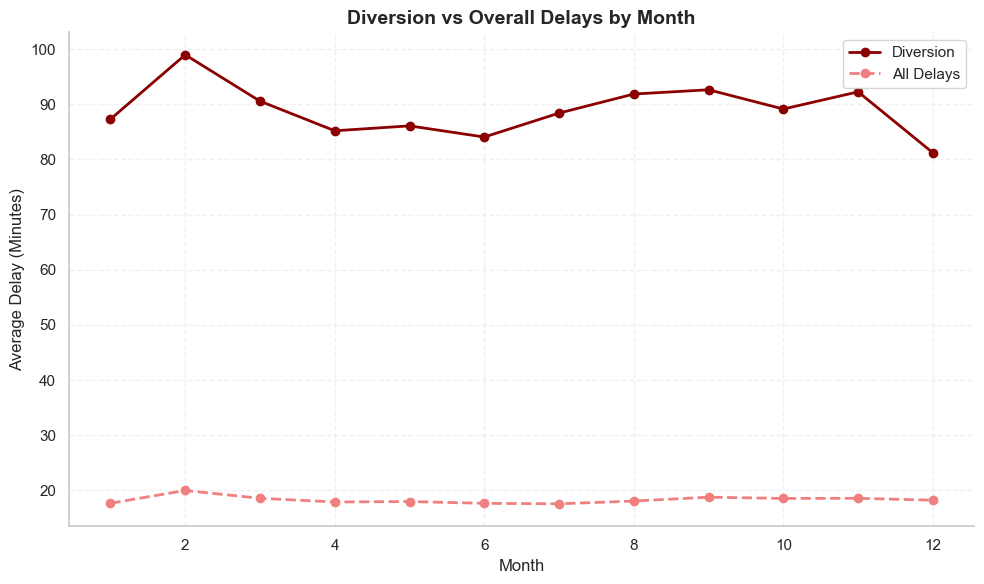

In [ ]:
all_month = df.groupby("month")["delay_minutes"].mean().sort_index()
plt.figure(figsize=(10, 6))

plt.plot(div_month.index, div_month.values,
         marker='o', linewidth=2, color='darkred', label="Diversion")

plt.plot(all_month.index, all_month.values,
         marker='o', linewidth=2, linestyle='--', color='lightcoral', label="All Delays")

plt.xlabel("Month")
plt.ylabel("Average Delay (Minutes)")
plt.title("Diversion vs Overall Delays by Month", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
div_route = diversion.groupby("route")["delay_minutes"].mean().sort_values(ascending=False)
display(div_route.head(10))

route
YU     450.000000
117    303.000000
610    270.000000
340    204.000000
504    180.000000
55     159.500000
171    155.818182
93     152.200000
77     150.075000
154    146.750000
Name: delay_minutes, dtype: float64

In [ ]:
df.groupby("incident")["delay_minutes"].sum().sort_values(ascending=False)

incident
Diversion                           998070.0
Mechanical                          793368.0
Operations - Operator               574128.0
General Delay                       196305.0
Security                            158809.0
Collision - TTC                     143780.0
Utilized Off Route                  118453.0
Emergency Services                  108046.0
Cleaning - Unsanitary                88539.0
Road Blocked - NON-TTC Collision     71143.0
Investigation                        60145.0
Vision                               49896.0
Late Leaving Garage                  14978.0
Held By                              11469.0
Cleaning                             11059.0
Late Leaving Garage - Mechanical      3143.0
Late Leaving Garage - Operator        1622.0
Late Entering Service                  782.0
Late Leaving Garage - Management       598.0
Cleaning - Disinfection                536.0
Late Leaving Garage - Vision           279.0
Late Leaving Garage - Operations        30.0
M

# Next steps

Interpreting this data and seeing what is most useful: 
- Make strong connections
- Is there a big difference? obvious trend? Or is it kinda weak / noisy?
- What affects delay duration? What helps prediction?
- Chose our strongest points and graphs (4-5)
- Since this is a visualization course we want to make the graphs we choose as good as possible with what we learnt in class
